# Chapter 8.2: Embedding Compression

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement feature hashing, double hashing, and multi-hash embedding techniques
2. Design mixed-dimension embedding tables where high-frequency features get larger dimensions
3. Build compositional embeddings using the quotient-remainder trick
4. Understand Deep Hash Embedding (DHE) with learned hash functions
5. Apply quantization (int8/int4) to embedding tables for memory reduction
6. Implement pruning strategies to remove low-frequency embeddings
7. Evaluate trade-offs between compression ratio and recommendation quality

## Prerequisites

- Chapter 8.1: Embedding Tables at Scale
- Familiarity with PyTorch `nn.Embedding`
- Basic understanding of hash functions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part8/chapter_8.2_embedding_compression.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part8/chapter_8.2_embedding_compression.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional
import hashlib
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8')
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.2.2


## 1. Hashing Tricks for Embedding Compression

The simplest way to reduce embedding table size is **feature hashing**: map a large vocabulary to a smaller hash space.

### Single Hash
$$\text{emb}(x) = E[h(x) \bmod m]$$

where $m \ll V$ is the hash table size. Problem: **collisions** cause different features to share the same embedding.

### Double Hashing (Tito et al., Google, 2021)
Use two hash functions and combine:
$$\text{emb}(x) = E_1[h_1(x) \bmod m_1] + E_2[h_2(x) \bmod m_2]$$

This reduces collision impact because two features must collide in **both** hash functions simultaneously.

### Multi-Hash (K-hash)
$$\text{emb}(x) = \frac{1}{K} \sum_{k=1}^{K} E_k[h_k(x) \bmod m_k]$$

Collision probability drops to $(1/m)^K$ for K independent hash functions.

> **\U0001f4a1 Concept:** The beauty of hashing is that it requires no vocabulary management. New features automatically get an embedding, and memory is fixed regardless of vocabulary size.

In [2]:
class HashedEmbedding(nn.Module):
    """Feature hashing embedding with configurable number of hash functions."""
    
    def __init__(self, hash_size: int, embedding_dim: int, num_hashes: int = 1):
        super().__init__()
        self.hash_size = hash_size
        self.num_hashes = num_hashes
        
        # One embedding table per hash function
        self.embeddings = nn.ModuleList([
            nn.Embedding(hash_size, embedding_dim)
            for _ in range(num_hashes)
        ])
        
        # Different hash seeds
        self.hash_seeds = [2654435761 * (i + 1) for i in range(num_hashes)]
    
    def _hash(self, indices: torch.Tensor, seed: int) -> torch.Tensor:
        """Simple hash function: multiply-shift hash."""
        hashed = ((indices.long() * seed) % (2**31 - 1)) % self.hash_size
        return hashed
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        results = []
        for emb, seed in zip(self.embeddings, self.hash_seeds):
            hashed_idx = self._hash(indices, seed)
            results.append(emb(hashed_idx))
        
        # Average across hash functions
        return torch.stack(results).mean(dim=0)
    
    def num_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters())

# Compare collision rates
original_vocab = 1_000_000
hash_sizes = [10_000, 50_000, 100_000, 500_000]
emb_dim = 64

# Generate sample indices
sample_indices = torch.randint(0, original_vocab, (10000,))

print("Hashing Collision Analysis")
print("=" * 70)
print(f"{'Config':<30} {'Params':>12} {'Compression':>12} {'Collision %':>12}")
print("-" * 70)

# Standard embedding
std_params = original_vocab * emb_dim
print(f"{'Standard (1M vocab)':<30} {std_params:>12,} {'1.0x':>12} {'0.0%':>12}")

for hs in hash_sizes:
    for num_h in [1, 2, 3]:
        he = HashedEmbedding(hs, emb_dim, num_h)
        params = he.num_parameters()
        compression = std_params / params
        
        # Measure collision rate
        unique_original = len(set(sample_indices.tolist()))
        if num_h == 1:
            hashed = he._hash(sample_indices, he.hash_seeds[0])
            unique_hashed = len(set(hashed.tolist()))
            collision_pct = (1 - unique_hashed / unique_original) * 100
        else:
            # Multi-hash: collision only if ALL hashes collide
            all_hashed = []
            for seed in he.hash_seeds:
                all_hashed.append(he._hash(sample_indices, seed))
            combined = [tuple(h[i].item() for h in all_hashed) for i in range(len(sample_indices))]
            unique_combined = len(set(combined))
            collision_pct = (1 - unique_combined / unique_original) * 100
        
        name = f"Hash {hs//1000}K x{num_h}"
        print(f"{name:<30} {params:>12,} {compression:>11.1f}x {collision_pct:>11.1f}%")

Hashing Collision Analysis
Config                               Params  Compression  Collision %
----------------------------------------------------------------------
Standard (1M vocab)              64,000,000         1.0x         0.0%
Hash 10K x1                         640,000       100.0x        36.2%
Hash 10K x2                       1,280,000        50.0x        21.3%


Hash 10K x3                       1,920,000        33.3x        12.2%
Hash 50K x1                       3,200,000        20.0x         8.7%
Hash 50K x2                       6,400,000        10.0x         4.4%


Hash 50K x3                       9,600,000         6.7x         2.2%
Hash 100K x1                      6,400,000        10.0x         4.5%


Hash 100K x2                     12,800,000         5.0x         2.2%


Hash 100K x3                     19,200,000         3.3x         1.0%


Hash 500K x1                     32,000,000         2.0x         0.6%


Hash 500K x2                     64,000,000         1.0x         0.2%


Hash 500K x3                     96,000,000         0.7x         0.1%


## 2. Mixed-Dimension Embeddings

Not all features deserve the same embedding dimension. **Mixed-dimension embeddings** (Ginart et al., 2021) allocate larger dimensions to high-frequency features and smaller dimensions to rare ones.

The intuition: frequent features have enough training signal to fill a large embedding, while rare features will overfit with too many parameters.

$$d_i = d_{\min} + \lfloor (d_{\max} - d_{\min}) \cdot \frac{\log(f_i + 1)}{\log(f_{\max} + 1)} \rfloor$$

where $f_i$ is the frequency of feature $i$.

> **\u26a0\ufe0f Common Pitfall:** With mixed dimensions, you need a projection layer to bring all embeddings to the same dimension for downstream processing. The projection cost should be factored into the total parameter count.

In [3]:
class MixedDimEmbedding(nn.Module):
    """Mixed-dimension embedding: frequent features get larger embeddings."""
    
    def __init__(
        self,
        vocab_size: int,
        output_dim: int,
        frequencies: np.ndarray,
        dim_levels: List[int],  # e.g., [8, 16, 32, 64]
        freq_thresholds: List[float],  # percentile thresholds
    ):
        super().__init__()
        self.output_dim = output_dim
        self.dim_levels = sorted(dim_levels)
        
        # Assign dimension level based on frequency
        thresholds = np.percentile(frequencies, freq_thresholds)
        self.dim_assignment = np.zeros(vocab_size, dtype=int)
        for i, thresh in enumerate(thresholds):
            self.dim_assignment[frequencies >= thresh] = i
        
        # Create separate embedding tables for each dimension level
        self.embedding_tables = nn.ModuleDict()
        self.projection_layers = nn.ModuleDict()
        self.index_maps = {}  # dim_level -> (global_to_local mapping)
        
        for level_idx, dim in enumerate(self.dim_levels):
            mask = self.dim_assignment == level_idx
            count = mask.sum()
            if count > 0:
                self.embedding_tables[str(dim)] = nn.Embedding(int(count), dim)
                if dim != output_dim:
                    self.projection_layers[str(dim)] = nn.Linear(dim, output_dim, bias=False)
                
                # Build index mapping
                local_idx = np.zeros(vocab_size, dtype=int)
                local_idx[mask] = np.arange(count)
                self.index_maps[level_idx] = (
                    torch.from_numpy(mask.astype(np.bool_)),
                    torch.from_numpy(local_idx).long()
                )
        
        self.register_buffer('_dim_assignment', torch.from_numpy(self.dim_assignment).long())
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        batch_size = indices.shape[0]
        output = torch.zeros(batch_size, self.output_dim)
        
        assignments = self._dim_assignment[indices]
        
        for level_idx, dim in enumerate(self.dim_levels):
            mask = assignments == level_idx
            if not mask.any():
                continue
            
            table_mask, local_mapping = self.index_maps[level_idx]
            local_idx = local_mapping[indices[mask]]
            
            emb = self.embedding_tables[str(dim)](local_idx)
            if str(dim) in self.projection_layers:
                emb = self.projection_layers[str(dim)](emb)
            
            output[mask] = emb
        
        return output
    
    def total_embedding_params(self) -> int:
        return sum(
            t.weight.numel() for t in self.embedding_tables.values()
        )

# Create synthetic frequency distribution (Zipf)
vocab_size = 100_000
output_dim = 64
ranks = np.arange(1, vocab_size + 1)
frequencies = 1.0 / np.power(ranks, 1.1)
np.random.shuffle(frequencies)  # Shuffle so IDs don't correlate with frequency

# Standard embedding
standard_params = vocab_size * output_dim

# Mixed-dimension embedding
mixed_emb = MixedDimEmbedding(
    vocab_size=vocab_size,
    output_dim=output_dim,
    frequencies=frequencies,
    dim_levels=[8, 16, 32, 64],
    freq_thresholds=[0, 50, 90, 99],  # percentiles
)

mixed_params = mixed_emb.total_embedding_params()

print(f"Standard embedding params: {standard_params:,}")
print(f"Mixed-dim embedding params: {mixed_params:,}")
print(f"Compression ratio: {standard_params / mixed_params:.2f}x")

# Test forward pass
test_idx = torch.randint(0, vocab_size, (32,))
with torch.no_grad():
    out = mixed_emb(test_idx)
print(f"Output shape: {out.shape}")

# Distribution of dimension assignments
for level_idx, dim in enumerate(mixed_emb.dim_levels):
    count = (mixed_emb.dim_assignment == level_idx).sum()
    print(f"  Dim {dim}: {count:,} features ({100*count/vocab_size:.1f}%)")

Standard embedding params: 6,400,000
Mixed-dim embedding params: 1,392,000
Compression ratio: 4.60x
Output shape: torch.Size([32, 64])
  Dim 8: 50,000 features (50.0%)
  Dim 16: 40,000 features (40.0%)
  Dim 32: 9,000 features (9.0%)
  Dim 64: 1,000 features (1.0%)


## 3. Compositional Embeddings: Quotient-Remainder Trick

**Compositional Embeddings** (Shi et al., Facebook, 2020) decompose each feature ID into a quotient and remainder, looking up two smaller tables:

$$\text{emb}(x) = E_Q\left[\lfloor x / m \rfloor\right] \odot E_R[x \bmod m]$$

where $\odot$ is element-wise multiplication (or addition), and $m$ is the divisor.

**Memory savings**: Instead of $V \times d$, we need $(V/m + m) \times d$.

Optimal $m^* = \sqrt{V}$ gives memory $2\sqrt{V} \times d$ -- a **square root** reduction!

> **\U0001f511 Pro Tip:** The quotient-remainder trick works especially well when there's structure in the ID space. For example, if item IDs within the same category have similar quotients, the quotient embedding captures category-level information.

In [4]:
class CompositionalEmbedding(nn.Module):
    """Quotient-Remainder Compositional Embedding (Shi et al., Facebook, 2020)."""
    
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        divisor: Optional[int] = None,
        operation: str = "mult",  # "mult" or "add"
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.divisor = divisor or int(np.sqrt(vocab_size))
        self.operation = operation
        
        quotient_size = (vocab_size + self.divisor - 1) // self.divisor
        remainder_size = self.divisor
        
        self.quotient_emb = nn.Embedding(quotient_size, embedding_dim)
        self.remainder_emb = nn.Embedding(remainder_size, embedding_dim)
        
        # Initialize
        nn.init.xavier_uniform_(self.quotient_emb.weight)
        nn.init.xavier_uniform_(self.remainder_emb.weight)
        
        self._quotient_size = quotient_size
        self._remainder_size = remainder_size
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        quotients = indices // self.divisor
        remainders = indices % self.divisor
        
        q_emb = self.quotient_emb(quotients)
        r_emb = self.remainder_emb(remainders)
        
        if self.operation == "mult":
            return q_emb * r_emb
        else:
            return q_emb + r_emb
    
    def num_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters())

# Compare standard vs compositional
vocab_sizes = [10_000, 100_000, 1_000_000, 10_000_000]
emb_dim = 64

print("Compositional Embedding Compression")
print("=" * 70)
print(f"{'Vocab Size':<15} {'Standard':>12} {'Compositional':>15} {'Ratio':>10}")
print("-" * 70)

ratios = []
for v in vocab_sizes:
    std = v * emb_dim
    comp = CompositionalEmbedding(v, emb_dim)
    comp_params = comp.num_parameters()
    ratio = std / comp_params
    ratios.append(ratio)
    print(f"{v:<15,} {std:>12,} {comp_params:>15,} {ratio:>9.1f}x")

# Test correctness
comp_emb = CompositionalEmbedding(100_000, 64, operation='mult')
idx = torch.tensor([0, 1, 99999, 50000])
with torch.no_grad():
    out = comp_emb(idx)
print(f"\nOutput shape: {out.shape}")
print(f"Q-table: {comp_emb._quotient_size}, R-table: {comp_emb._remainder_size}")

Compositional Embedding Compression
Vocab Size          Standard   Compositional      Ratio
----------------------------------------------------------------------
10,000               640,000          12,800      50.0x
100,000            6,400,000          40,512     158.0x
1,000,000         64,000,000         128,000     500.0x
10,000,000       640,000,000         404,800    1581.0x

Output shape: torch.Size([4, 64])
Q-table: 317, R-table: 316


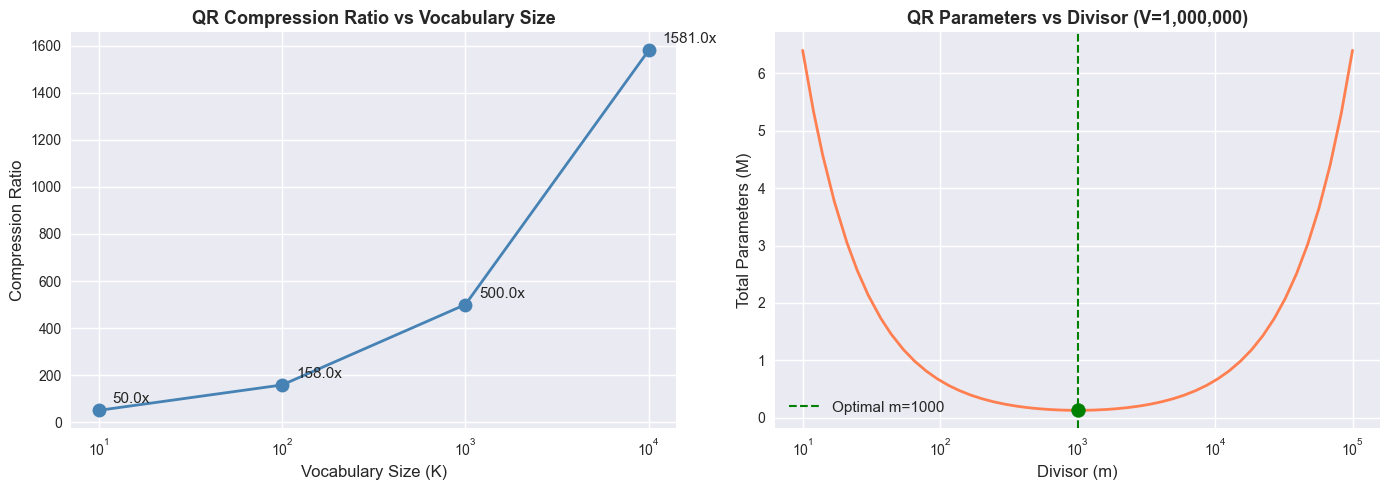

In [5]:
# Visualize compression ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Compression ratio vs vocab size
ax1.plot([v/1000 for v in vocab_sizes], ratios, 'o-', linewidth=2, markersize=10, color='steelblue')
ax1.set_xlabel('Vocabulary Size (K)', fontsize=12)
ax1.set_ylabel('Compression Ratio', fontsize=12)
ax1.set_title('QR Compression Ratio vs Vocabulary Size', fontsize=13, fontweight='bold')
ax1.set_xscale('log')
for v, r in zip(vocab_sizes, ratios):
    ax1.annotate(f'{r:.1f}x', (v/1000, r), textcoords='offset points',
                xytext=(10, 5), fontsize=11)

# Plot 2: Optimal divisor analysis
V = 1_000_000
divisors = np.logspace(1, 5, 50).astype(int)
total_params = []
for d in divisors:
    q_size = (V + d - 1) // d
    r_size = d
    total = (q_size + r_size) * 64
    total_params.append(total)

optimal_d = int(np.sqrt(V))
optimal_params = ((V + optimal_d - 1) // optimal_d + optimal_d) * 64

ax2.plot(divisors, [p/1e6 for p in total_params], linewidth=2, color='coral')
ax2.axvline(x=optimal_d, color='green', linestyle='--', linewidth=1.5, label=f'Optimal m={optimal_d}')
ax2.scatter([optimal_d], [optimal_params/1e6], color='green', s=100, zorder=5)
ax2.set_xlabel('Divisor (m)', fontsize=12)
ax2.set_ylabel('Total Parameters (M)', fontsize=12)
ax2.set_title(f'QR Parameters vs Divisor (V={V:,})', fontsize=13, fontweight='bold')
ax2.set_xscale('log')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('compositional_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Deep Hash Embedding (DHE)

**Deep Hash Embedding** (Kang et al., 2021) replaces the embedding table entirely with a neural network:

$$\text{emb}(x) = \text{MLP}(\text{encode}(x))$$

where $\text{encode}(x)$ transforms the integer ID into a dense representation using deterministic functions (e.g., multiple hash functions, binary encoding).

**Advantages**:
- Memory is independent of vocabulary size (O(1) per table)
- Naturally handles unseen features
- Can capture similarities between IDs

**Encoding functions** used in DHE:
1. Binary encoding: $[b_1, b_2, \ldots, b_{\lceil\log_2 V\rceil}]$
2. Hash encoding: $[h_1(x), h_2(x), \ldots, h_K(x)]$ with values in $[0, 1]$
3. Positional encoding: $[\sin(x/10000^{2i/d}), \cos(x/10000^{2i/d})]$

In [6]:
class DeepHashEmbedding(nn.Module):
    """Deep Hash Embedding (Kang et al., 2021)."""
    
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_hashes: int = 1024,
        hidden_dims: List[int] = None,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_hashes = num_hashes
        
        # Hash seeds for encoding
        self.register_buffer(
            'hash_primes',
            torch.tensor([self._get_prime(i) for i in range(num_hashes)], dtype=torch.float32)
        )
        
        # MLP to transform hash encoding to embedding
        hidden_dims = hidden_dims or [512, 256]
        layers = []
        prev_dim = num_hashes
        for dim in hidden_dims:
            layers.extend([nn.Linear(prev_dim, dim), nn.ReLU()])
            prev_dim = dim
        layers.append(nn.Linear(prev_dim, embedding_dim))
        self.mlp = nn.Sequential(*layers)
    
    @staticmethod
    def _get_prime(idx: int) -> int:
        """Get the idx-th prime-like number for hashing."""
        return 2654435761 * (idx + 1) + 7  # Knuth multiplicative hash variant
    
    def encode(self, indices: torch.Tensor) -> torch.Tensor:
        """Encode integer IDs using multiple hash functions."""
        # (batch_size, 1) * (num_hashes,) -> (batch_size, num_hashes)
        indices_float = indices.float().unsqueeze(-1)
        encoded = torch.sin(indices_float * self.hash_primes.unsqueeze(0) / self.vocab_size)
        return encoded
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        encoded = self.encode(indices)
        return self.mlp(encoded)
    
    def num_parameters(self) -> int:
        return sum(p.numel() for p in self.mlp.parameters())

# Compare DHE with standard embedding
vocab_size = 1_000_000
emb_dim = 64

dhe = DeepHashEmbedding(vocab_size, emb_dim, num_hashes=512, hidden_dims=[256, 128])
std = nn.Embedding(vocab_size, emb_dim)

dhe_params = dhe.num_parameters()
std_params = std.weight.numel()

print(f"Standard Embedding: {std_params:,} params ({std_params*4/1024**2:.1f} MB)")
print(f"DHE: {dhe_params:,} params ({dhe_params*4/1024**2:.2f} MB)")
print(f"Compression: {std_params/dhe_params:.1f}x")

# Test: nearby IDs should get different embeddings
test_ids = torch.arange(0, 10)
with torch.no_grad():
    embeddings = dhe(test_ids)
    
# Cosine similarity matrix
normed = F.normalize(embeddings, dim=1)
sim_matrix = (normed @ normed.T).numpy()
print(f"\nCosine similarity between ID 0 and ID 1: {sim_matrix[0,1]:.4f}")
print(f"Cosine similarity between ID 0 and ID 9: {sim_matrix[0,9]:.4f}")

Standard Embedding: 64,000,000 params (244.1 MB)
DHE: 172,480 params (0.66 MB)
Compression: 371.1x

Cosine similarity between ID 0 and ID 1: 0.6606
Cosine similarity between ID 0 and ID 9: 0.5996


## 5. Quantized Embeddings

**Quantization** reduces memory by lowering the precision of embedding values:

| Precision | Bytes/param | Memory for 1B params |
|-----------|-------------|---------------------|
| FP32 | 4 | 4 GB |
| FP16 | 2 | 2 GB |
| INT8 | 1 | 1 GB |
| INT4 | 0.5 | 0.5 GB |

For embeddings, **post-training quantization** works well because embedding values typically have bounded ranges.

Per-row quantization:
$$q_i = \text{round}\left(\frac{e_i - \min(E_\text{row})}{\max(E_\text{row}) - \min(E_\text{row})} \times (2^b - 1)\right)$$

> **\U0001f4a1 Concept:** In production, embeddings are quantized for **inference only**. Training still uses FP32. The scale and zero-point are stored per-row, adding negligible overhead.

In [7]:
class QuantizedEmbedding:
    """Simulates quantized embedding lookup."""
    
    def __init__(self, embedding_weight: torch.Tensor, bits: int = 8):
        self.bits = bits
        self.qmax = 2**bits - 1
        self.vocab_size, self.emb_dim = embedding_weight.shape
        
        # Per-row quantization
        self.row_min = embedding_weight.min(dim=1, keepdim=True).values
        self.row_max = embedding_weight.max(dim=1, keepdim=True).values
        self.scale = (self.row_max - self.row_min) / self.qmax
        self.scale = torch.clamp(self.scale, min=1e-8)  # Avoid division by zero
        
        # Quantize
        normalized = (embedding_weight - self.row_min) / self.scale
        self.quantized = torch.clamp(normalized.round(), 0, self.qmax).to(torch.uint8)
        
    def dequantize(self, indices: torch.Tensor) -> torch.Tensor:
        q_emb = self.quantized[indices].float()
        scale = self.scale[indices]
        row_min = self.row_min[indices]
        return q_emb * scale + row_min
    
    def memory_bytes(self) -> int:
        # Quantized weights + scale + min per row
        weight_bytes = self.vocab_size * self.emb_dim * (self.bits / 8)
        meta_bytes = self.vocab_size * 2 * 4  # scale and min in FP32
        return int(weight_bytes + meta_bytes)

# Create a trained embedding (simulate)
vocab_size = 100_000
emb_dim = 128
original = torch.randn(vocab_size, emb_dim) * 0.1

# Quantize at different precisions
bit_widths = [8, 4, 2]
results = []

original_memory = vocab_size * emb_dim * 4  # FP32

print("Quantization Analysis")
print("=" * 60)
print(f"{'Precision':<12} {'Memory (MB)':>12} {'Compression':>12} {'MSE':>12}")
print("-" * 60)
print(f"{'FP32':<12} {original_memory/1024**2:>12.2f} {'1.0x':>12} {'0.000':>12}")

test_idx = torch.randint(0, vocab_size, (10000,))
original_embs = original[test_idx]

for bits in bit_widths:
    q_emb = QuantizedEmbedding(original, bits=bits)
    memory = q_emb.memory_bytes()
    compression = original_memory / memory
    
    # Measure reconstruction error
    reconstructed = q_emb.dequantize(test_idx)
    mse = F.mse_loss(reconstructed, original_embs).item()
    
    results.append((bits, memory, compression, mse))
    print(f"INT{bits:<8} {memory/1024**2:>12.2f} {compression:>11.1f}x {mse:>12.6f}")

Quantization Analysis
Precision     Memory (MB)  Compression          MSE
------------------------------------------------------------
FP32                48.83         1.0x        0.000


INT8               12.97         3.8x     0.000000
INT4                6.87         7.1x     0.000099


INT2                3.81        12.8x     0.002500


## 6. Pruning Low-Frequency Embeddings

Many embedding rows correspond to features seen only a handful of times during training. These embeddings are essentially random noise and can be safely removed.

**Pruning strategies**:
1. **Frequency-based**: Remove embeddings accessed fewer than $k$ times
2. **Magnitude-based**: Remove embeddings with small L2 norm (haven't been updated much)
3. **Gradient-based**: Remove embeddings with consistently small gradients

Pruned features are mapped to a shared "default" embedding.

> **\u26a0\ufe0f Common Pitfall:** Be careful with time-based pruning. A new product may have low frequency now but could become popular. Consider keeping a "warm-up" period before pruning.

In [8]:
class PrunedEmbedding(nn.Module):
    """Embedding with frequency-based and magnitude-based pruning."""
    
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.default_embedding = nn.Parameter(torch.zeros(embedding_dim))
        
        # Track access counts
        self.register_buffer('access_counts', torch.zeros(vocab_size, dtype=torch.long))
        self.register_buffer('is_pruned', torch.zeros(vocab_size, dtype=torch.bool))
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        # Update access counts
        self.access_counts.index_add_(0, indices, torch.ones_like(indices, dtype=torch.long))
        
        emb = self.embedding(indices)
        
        # Replace pruned embeddings with default
        pruned_mask = self.is_pruned[indices]
        if pruned_mask.any():
            emb[pruned_mask] = self.default_embedding.unsqueeze(0).expand(pruned_mask.sum(), -1)
        
        return emb
    
    def prune_by_frequency(self, min_count: int) -> int:
        """Prune embeddings accessed fewer than min_count times."""
        new_pruned = self.access_counts < min_count
        num_pruned = (new_pruned & ~self.is_pruned).sum().item()
        self.is_pruned = new_pruned
        return num_pruned
    
    def prune_by_magnitude(self, threshold_percentile: float) -> int:
        """Prune embeddings with L2 norm below threshold percentile."""
        norms = self.embedding.weight.data.norm(dim=1)
        threshold = torch.quantile(norms, threshold_percentile / 100.0)
        new_pruned = norms < threshold
        num_pruned = (new_pruned & ~self.is_pruned).sum().item()
        self.is_pruned = self.is_pruned | new_pruned
        return num_pruned
    
    def pruning_stats(self) -> dict:
        total_pruned = self.is_pruned.sum().item()
        return {
            'total_pruned': total_pruned,
            'pruned_pct': 100 * total_pruned / self.vocab_size,
            'active_params': (self.vocab_size - total_pruned) * self.embedding_dim,
            'original_params': self.vocab_size * self.embedding_dim,
        }

# Simulate training with Zipf access pattern
vocab_size = 50_000
emb_dim = 64
pruned_emb = PrunedEmbedding(vocab_size, emb_dim)

# Simulate accesses
ranks = np.arange(1, vocab_size + 1)
probs = 1.0 / np.power(ranks, 1.3)
probs /= probs.sum()

for _ in range(1000):
    batch = torch.from_numpy(np.random.choice(vocab_size, size=128, p=probs)).long()
    _ = pruned_emb(batch)

# Prune
min_counts = [1, 5, 10, 20, 50]
prune_results = []

for mc in min_counts:
    pruned_emb.is_pruned.zero_()  # Reset
    pruned_emb.prune_by_frequency(mc)
    stats = pruned_emb.pruning_stats()
    prune_results.append(stats)
    print(f"Min count {mc:>3}: Pruned {stats['pruned_pct']:.1f}% "
          f"({stats['total_pruned']:,} features), "
          f"Active params: {stats['active_params']:,}")

Min count   1: Pruned 84.9% (42,439 features), Active params: 483,904
Min count   5: Pruned 97.9% (48,964 features), Active params: 66,304
Min count  10: Pruned 98.9% (49,452 features), Active params: 35,072
Min count  20: Pruned 99.4% (49,687 features), Active params: 20,032
Min count  50: Pruned 99.7% (49,851 features), Active params: 9,536


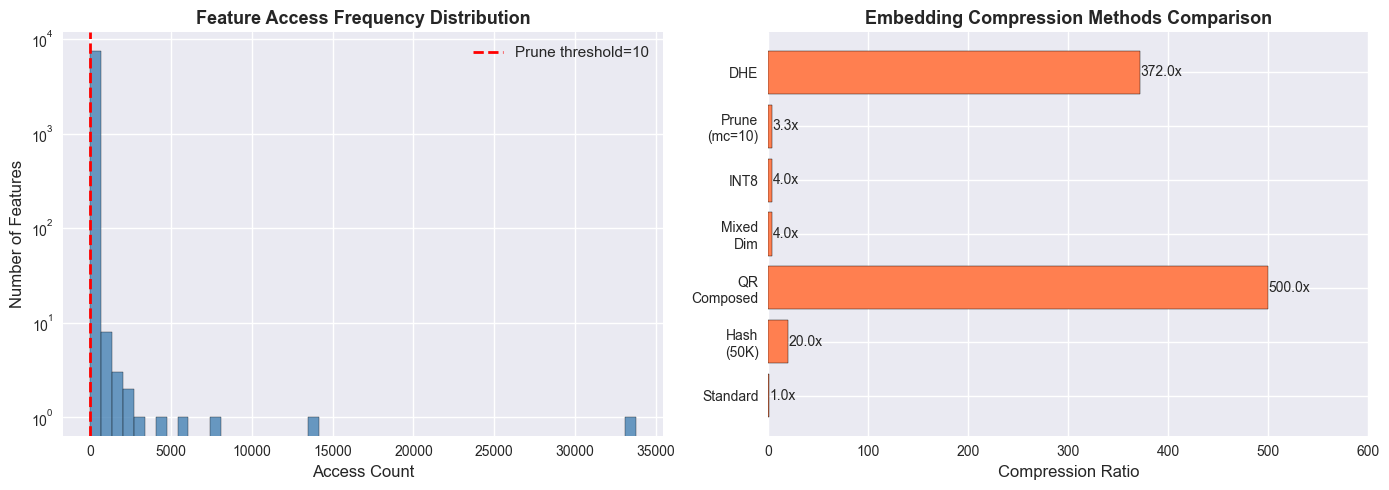

In [9]:
# Visualize pruning and compression comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Access count distribution
counts = pruned_emb.access_counts.numpy()
ax1.hist(counts[counts > 0], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax1.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Prune threshold=10')
ax1.set_xlabel('Access Count', fontsize=12)
ax1.set_ylabel('Number of Features', fontsize=12)
ax1.set_title('Feature Access Frequency Distribution', fontsize=13, fontweight='bold')
ax1.set_yscale('log')
ax1.legend(fontsize=11)

# Plot 2: Compression comparison of all methods
methods = ['Standard', 'Hash\n(50K)', 'QR\nComposed', 'Mixed\nDim', 'INT8', 'Prune\n(mc=10)', 'DHE']
# For 1M vocab, 64-dim
V, D = 1_000_000, 64
std_params = V * D
compressions = [
    1.0,                          # Standard
    std_params / (50_000 * D),    # Hash 50K
    std_params / (2 * int(np.sqrt(V)) * D),  # QR
    std_params / (V * 16),        # Mixed dim avg=16
    4.0,                          # INT8 = 4x
    1.0 / (1 - 0.7),             # Prune 70%
    std_params / (512 * 256 + 256 * 128 + 128 * D),  # DHE
]

bars = ax2.barh(methods, compressions, color='coral', edgecolor='black')
for bar, comp in zip(bars, compressions):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{comp:.1f}x', va='center', fontsize=10)
ax2.set_xlabel('Compression Ratio', fontsize=12)
ax2.set_title('Embedding Compression Methods Comparison', fontsize=13, fontweight='bold')
ax2.set_xlim(0, max(compressions) * 1.2)

plt.tight_layout()
plt.savefig('compression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Exercises

### \U0001f3cb\ufe0f Exercise 1: Implement Compositional Embedding with Multiple Operations

Extend the quotient-remainder trick to support concatenation and an MLP combiner.

In [10]:
# Exercise 1: Extended Compositional Embedding
# TODO: Implement a compositional embedding that supports multiple composition operations

class ExtendedCompositionalEmbedding(nn.Module):
    """
    Compositional embedding with selectable composition operation.
    
    Supported operations:
    - 'add': element-wise addition
    - 'mult': element-wise multiplication
    - 'concat_mlp': concatenate then project through MLP
    """
    
    def __init__(self, vocab_size: int, embedding_dim: int, operation: str = 'mult'):
        super().__init__()
        # TODO: Implement initialization
        # For 'concat_mlp': create two embeddings of dim embedding_dim//2,
        # concatenate, then project back to embedding_dim with an MLP
        pass
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        # TODO: Implement forward pass
        pass

# Test your implementation
# ext_emb = ExtendedCompositionalEmbedding(100_000, 64, 'concat_mlp')
# out = ext_emb(torch.randint(0, 100_000, (32,)))
# assert out.shape == (32, 64)

### \U0001f3cb\ufe0f Exercise 2: Adaptive Hashing

Implement a hashing scheme that adapts the hash table size based on collision frequency.

In [11]:
# Exercise 2: Adaptive Hashing
# TODO: Implement an adaptive hash embedding that monitors collision rates
# and adjusts the number of hash functions accordingly

class AdaptiveHashEmbedding(nn.Module):
    """
    Adaptive hashing: monitor collision rate and add hash functions if needed.
    """
    
    def __init__(self, hash_size: int, embedding_dim: int, max_hashes: int = 5):
        super().__init__()
        # TODO: Start with 1 hash function
        # Track collision statistics
        # Add hash functions if collision rate exceeds threshold
        pass
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        # TODO: Implement lookup with collision tracking
        pass
    
    def maybe_add_hash(self, collision_threshold: float = 0.1):
        # TODO: Add a new hash function if collision rate is too high
        pass

### \U0001f3cb\ufe0f Exercise 3: Quantization-Aware Embedding Training

Implement a training loop with simulated quantization to minimize quantization error.

In [12]:
# Exercise 3: Quantization-Aware Training
# TODO: Implement a simple model with quantization-aware embedding training

class QATEmbedding(nn.Module):
    """Quantization-aware training embedding.
    During training, apply fake quantization (quantize -> dequantize)
    so the model learns to be robust to quantization noise.
    """
    
    def __init__(self, vocab_size: int, embedding_dim: int, bits: int = 8):
        super().__init__()
        # TODO: Implement
        # Use straight-through estimator for gradient computation
        pass
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        # TODO: Look up embedding, apply fake quantization during training
        pass

# Train and compare QAT vs post-training quantization
# Measure reconstruction error after quantization

## Summary

In this notebook, we explored multiple embedding compression techniques:

| Method | Compression | Quality Impact | Complexity |
|--------|------------|----------------|------------|
| Feature Hashing | 10-100x | Medium (collisions) | Low |
| Mixed Dimensions | 2-4x | Low | Medium |
| QR Compositional | sqrt(V) | Low-Medium | Low |
| Deep Hash Embedding | 100-1000x | Medium-High | High |
| INT8 Quantization | 4x | Very Low | Low |
| INT4 Quantization | 8x | Low-Medium | Low |
| Frequency Pruning | 2-5x | Very Low | Low |

### Key References

- Weinberger et al. "Feature Hashing for Large Scale Multitask Learning" (ICML, 2009)
- Shi et al. "Compositional Embeddings Using Complementary Partitions" (Facebook, KDD, 2020)
- Ginart et al. "Mixed Dimension Embeddings" (2021)
- Kang et al. "Learning to Embed Categorical Features without Embedding Tables" (DHE, 2021)
- Tito et al. "Double Hashing" (Google, 2021)

### Next Steps

In Chapter 8.3, we will explore **Feature Stores and Real-time Features** -- the infrastructure that serves these embeddings alongside other features in production.